### Simple Conditional Workflow - no LLM

Example: Quadratic Equation

START --> input (a,b,c) --> show equation (ax2+bx+c) --> calculate discriminant (d = b2-4ac) --> go into one of the 3 branches depending on the value of d (d>0: two real roots or d=0: one repeated root or d<0: no real roots) --> END  

In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [4]:
def show_equation(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    equation = f"{a}x2 + {b}x + {c} = 0"
    return {'equation': equation}

def calculate_d(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    d = ((b**2) - (4*a*c))/(2*a)
    
    return {'d': d}

In [5]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: int
    d: float
    result: str

In [8]:
def real_roots(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']

    root1 = (-b + (b**2 - 4*a*c)**0.5) / (2*a)
    root2 = (-b - (b**2 - 4*a*c)**0.5) / (2*a)

    result = f"The roots of the equation are {root1} and {root2}."
    return {'result': result}

def repeated_root(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']

    root = -b / (2*a)

    result = f"The root of the equation is {root}."
    return {'result': result}

def no_roots(state: QuadState):

    result = f"The equation has no real roots."
    
    return {'result': result}

In [13]:
# now for conditional workflow, we need to make a new function which takes state as input and returns the one function name out of many branches we might have as output
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_root', 'no_roots']:
    
    d = state['d']
    
    if d > 0:
        return 'real_roots'
    elif d == 0:
        return 'repeated_root'
    else:
        return 'no_roots'

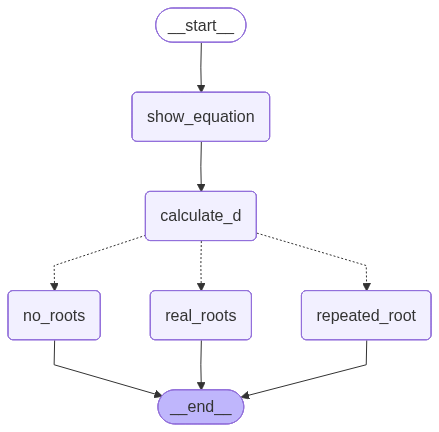

In [15]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_d', calculate_d)

graph.add_node('real_roots', real_roots)
graph.add_node('repeated_root', repeated_root)
graph.add_node('no_roots', no_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_d')

graph.add_conditional_edges('calculate_d', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('repeated_root', END)
graph.add_edge('no_roots', END)

workflow = graph.compile()
workflow

Note the dotted arrows representing conditional edges.

In [16]:
initial_state = {'a': 1, 'b': -3, 'c': 2}
final_state = workflow.invoke(initial_state)
final_state

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x2 + -3x + 2 = 0',
 'd': 0.5,
 'result': 'The roots of the equation are 2.0 and 1.0.'}